# 2 建模方法

> **图 2.1**：采用 10 个等距设计点（左图）与 10 个切比雪夫设计点（右图）进行多项式插值。

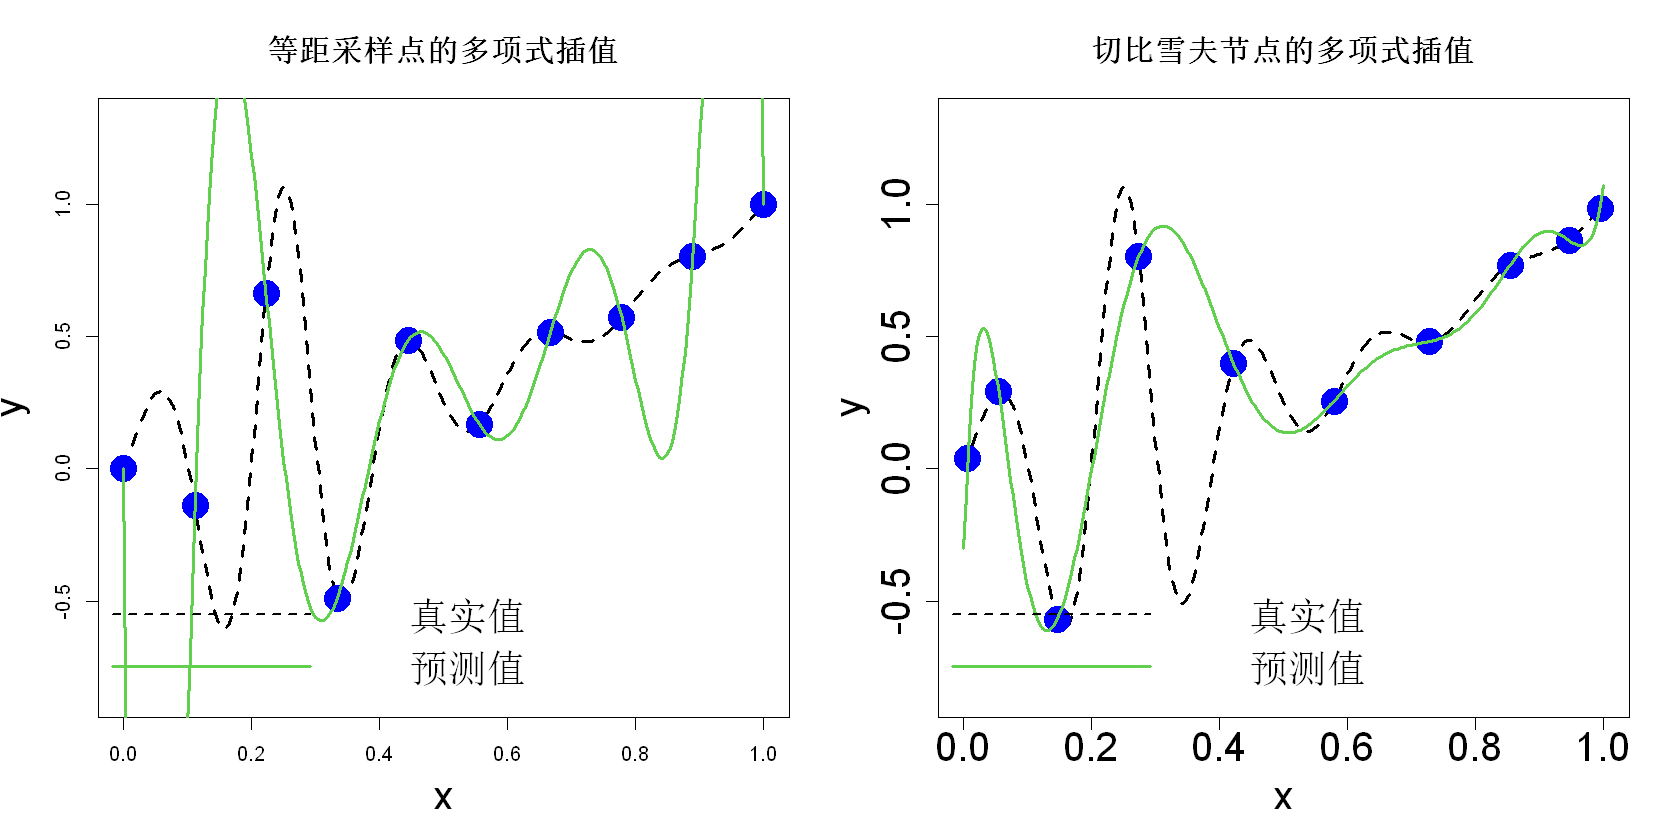

In [11]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/2.1-plot.RData")){
  f=function(x) sin(10*pi*x)/(1+64*(x-.25)^2)+x^2
  test=seq(0,1,length=301) # 301x1
  true=f(test) # 301x1
  n=10
  #等距设计点
  D1=((1:n)-1)/(n-1) # 10x1
  y1=f(D1) # 10x1
  d=2*D1-1
  X=NULL
  for(i in 1:n) X=cbind(X,cos((i-1)*acos(d)))
  a=solve(X,y1)
  u=seq(0,1,length=301)
  yhat1=u; us=2*u-1
  for(i in 1:301){
    yhat1[i]=0
    for(j in 1:n) yhat1[i]=yhat1[i]+a[j]*cos((j-1)*acos(us[i]))
  }
  #切比雪夫节点
  d=cos((2*(1:n)-1)/(2*n)*pi)
  D2=(d+1)/2 # 10x1
  y2=f(D2) # 10x1
  X=NULL
  for(i in 1:n) X=cbind(X,cos((i-1)*acos(d)))
  a=solve(X,y2)
  yhat2=u; us=2*u-1
  for(i in 1:301){
    yhat2[i]=0
    for(j in 1:n) yhat2[i]=yhat2[i]+a[j]*cos((j-1)*acos(us[i]))
  }
  save(D1,y1,D2,y2,test,true,yhat1,yhat2,file="data/2.1-plot.RData")
}

load("data/2.1-plot.RData")

options(repr.plot.width=14,repr.plot.height=7)
par(mfrow=c(1,2))
plot(test,true,type="l",xlab="x",ylab="y",lwd=3,lty=2,col=1,ylim=c(min(true)-.25,max(true)+.25),main="等距采样点的多项式插值",cex.main=1.5,cex.lab=2)
points(cbind(D1,y1),pch=16,cex=3,col="blue")
lines(test,yhat1,col=3,lwd=3)
legend("bottomright",legend=c("真实值","预测值"),lty=c(2,1),col=c(1,3),lwd=c(2,3),bty="n",cex=2)

plot(test,true,type="l",xlab="x",ylab="y",lwd=3,lty=2,col=1,ylim=c(min(true)-.25,max(true)+.25),main="切比雪夫节点的多项式插值",cex.main=1.5,cex.axis=2,cex.lab=2)
points(cbind(D2,y2),pch=16,cex=3,col="blue")
lines(test,yhat2,col=3,lwd=3)
legend("bottomright",legend=c("真实值","预测值"),lty=c(2,1),col=c(1,3),lwd=c(2,3),bty="n",cex=2)
par(mfrow=c(1,1))

> **图 2.2** 左图为 $2^2$ 试验设计，右图为将该设计中两个采样点施加扰动后得到的设计。

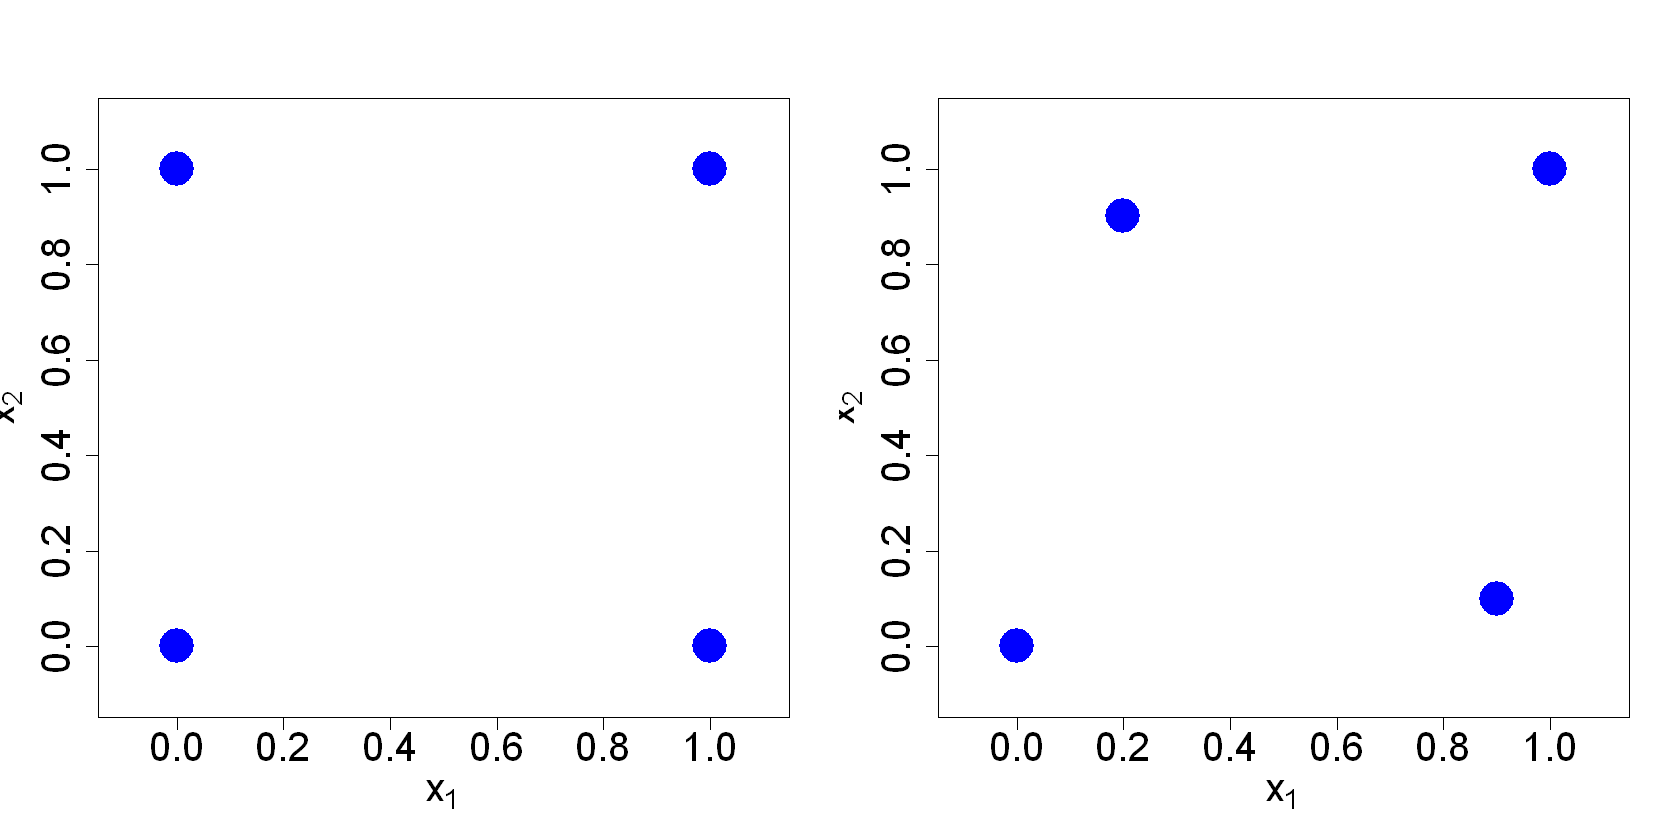

In [12]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/2.2-plot.RData")){
  D1=matrix(c(0,0,0,1,1,0,1,1),nrow=4,ncol=2,byrow=TRUE) # 4x2
  D2=matrix(c(0,0,.2,.9,.9,.1,1,1),nrow=4,ncol=2,byrow=TRUE) # 4x2
  save(D1,D2,file="data/2.2-plot.RData")
}

load("data/2.2-plot.RData")

options(repr.plot.width=14,repr.plot.height=7)
par(mfrow=c(1,2))
plot(D1,pch=16,cex=4,col="blue",xlim=c(-.1,1.1),ylim=c(-.1,1.1),xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,cex.axis=2)
plot(D2,pch=16,cex=4,col="blue",xlim=c(-.1,1.1),ylim=c(-.1,1.1),xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,cex.axis=2)
par(mfrow=c(1,1))

> **图 2.3** 采用 10 个等间距采样点，并为高斯径向基函数选取三组不同 $\theta$ 参数的径向基函数插值法。

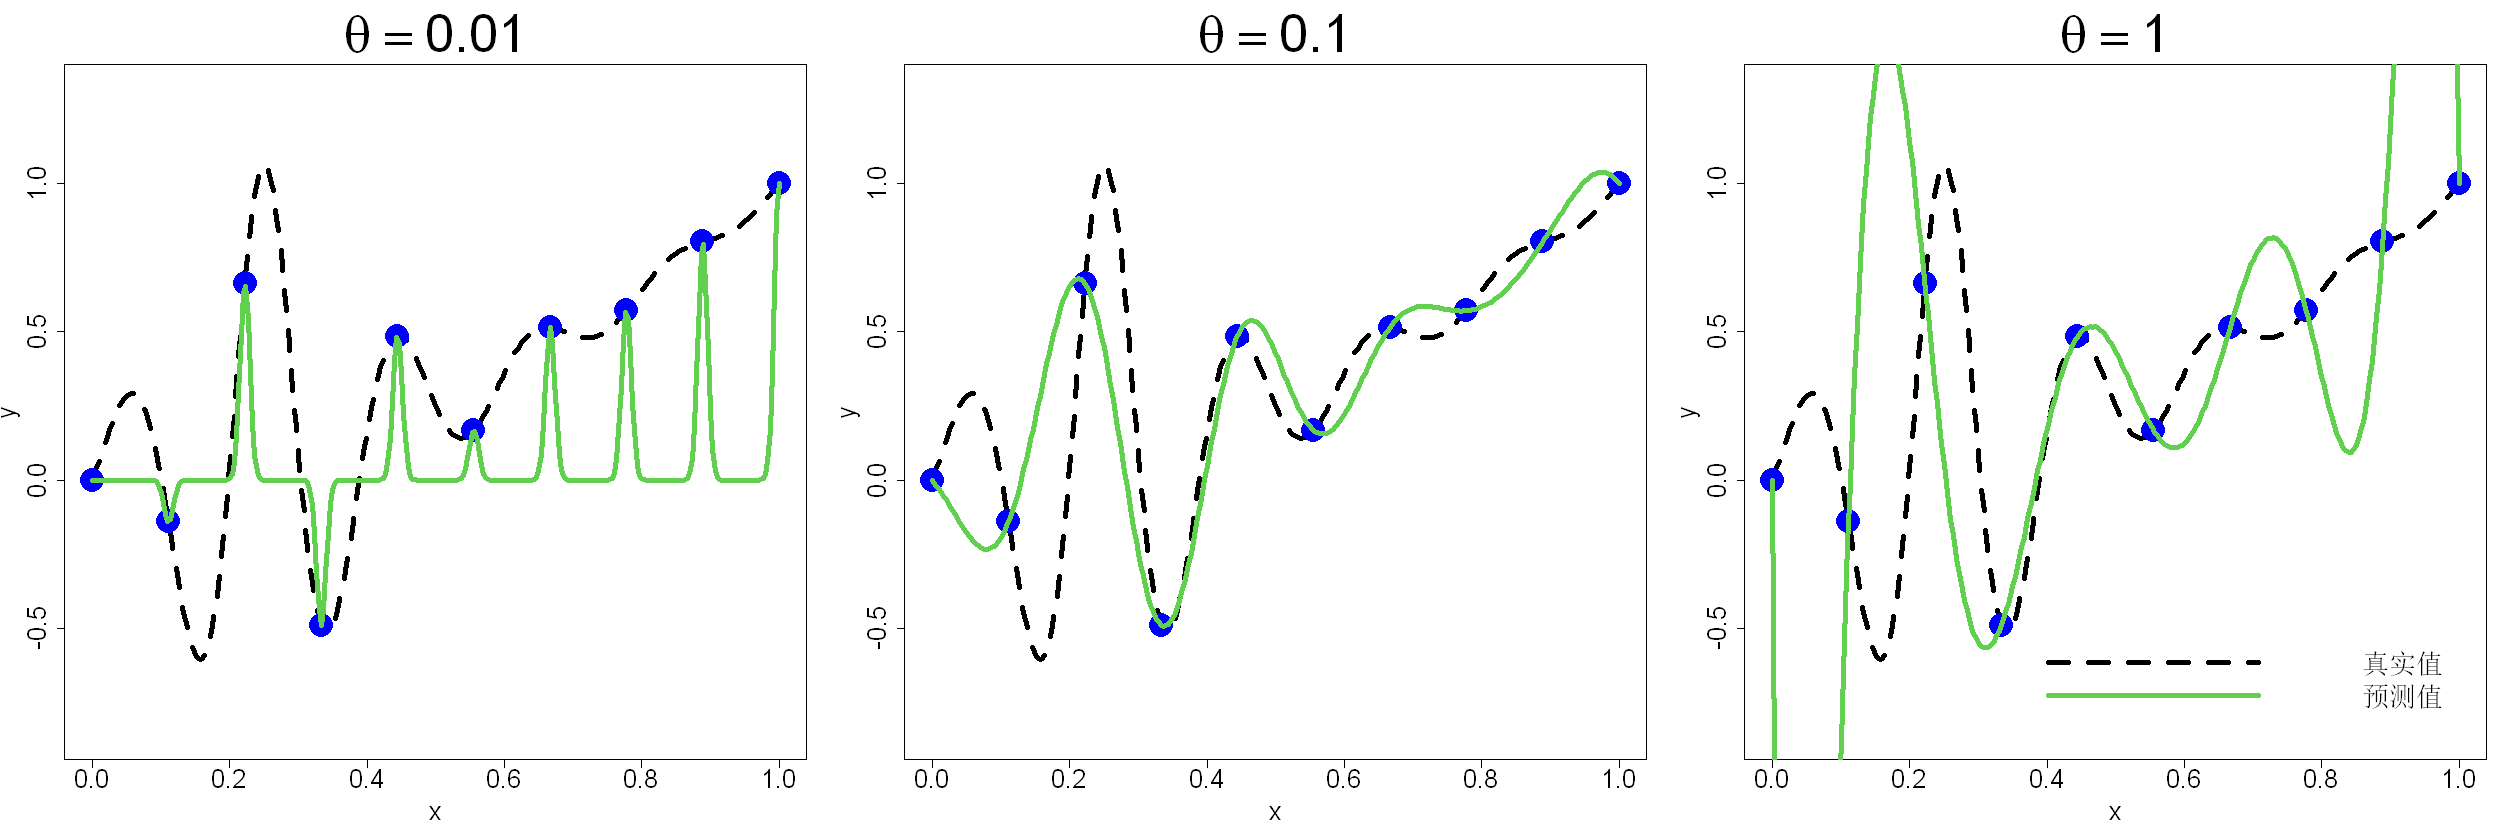

In [13]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/2.3-plot.RData")){
  f=function(x) sin(10*pi*x)/(1+64*(x-.25)^2)+x^2
  test=seq(0,1,length=301) # 301x1
  true=f(test) # 301x1
  n=10
  D=((1:n)-1)/(n-1) # 10x1
  y=f(D) # 10x1
  E=as.matrix(dist(D)) # 10x10
  predfun=function(theta){
    R=exp(-(E/theta)^2) # 10x10
    coef=solve(R,y) # 10x1
    pred=test
    for(i in 1:301){
      pred[i]=0
      for(j in 1:n) pred[i]=pred[i]+coef[j]*exp(-((test[i]-D[j])/theta)^2)
    }
    return(pred)
  }
  pred1=predfun(.01) # 301x1
  pred2=predfun(.1) # 301x1
  pred3=predfun(1) # 301x1
  MSCV=function(theta){
    R=exp(-(E/theta)^2)
    Rinv=solve(R)
    cv=c(Rinv%*%y)/diag(Rinv)
    val=log(mean(cv^2))
    return(val)
  }
  theta=optimize(MSCV,c(.01,.2))$min # 1x1
  save(D,y,test,true,pred1,pred2,pred3,file="data/2.3-plot.RData")
}

load("data/2.3-plot.RData")

options(repr.plot.width=21,repr.plot.height=7)
par(mfrow=c(1,3))
plot(test,true,type="l",lwd=4,lty=2,xlab="x",ylab="y",cex.lab=2,ylim=c(min(true)-.25,max(true)+.25),cex.axis=2,main=expression(theta==0.01),cex.main=4)
points(D,y,pch=16,cex=4,col="blue")
lines(test,pred1,col=3,lwd=4)
plot(test,true,type="l",lwd=4,lty=2,xlab="x",ylab="y",cex.lab=2,ylim=c(min(true)-.25,max(true)+.25),cex.axis=2,main=expression(theta==0.1),cex.main=4)
points(D,y,pch=16,cex=4,col="blue")
lines(test,pred2,col=3,lwd=4)
plot(test,true,type="l",lwd=4,lty=2,xlab="x",ylab="y",cex.lab=2,ylim=c(min(true)-.25,max(true)+.25),cex.axis=2,main=expression(theta==1),cex.main=4)
points(D,y,pch=16,cex=4,col="blue")
lines(test,pred3,col=3,lwd=4)
legend(.25,-.5,legend=c("真实值","预测值"),lty=c(2,1),col=c(1,3),lwd=c(4,4),bty="n",cex=2)

> **图 2.4** 一维实例下的普通克里金插值，95% 预测区间以阴影条带呈现。

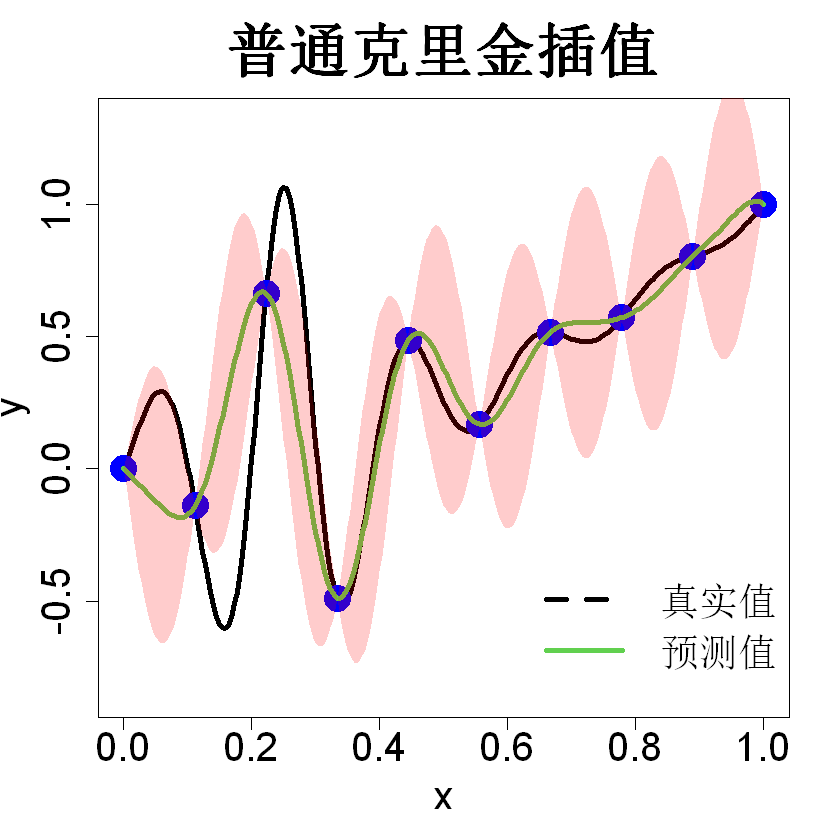

In [14]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/2.4-plot.RData")){
  f=function(x) sin(10*pi*x)/(1+64*(x-.25)^2)+x^2
  test=seq(0,1,length=301) # 301x1
  true=f(test) # 301x1
  n=10
  D=((1:n)-1)/(n-1) # 10x1
  y=f(D) # 10x1
  E=as.matrix(dist(D)) # 10x10
  theta=.08
  R=exp(-(E/theta)^2) # 10x10
  basis=function(h) exp(-(h/theta)^2)
  r=function(x) basis(x-D)
  one=rep(1,n) # 10x1
  Rinv=solve(R+10^(-10)*diag(n)) # 10x10
  mu=drop(t(one)%*%Rinv%*%y/(t(one)%*%Rinv%*%one)) # 1x1
  coef=Rinv%*%(y-mu) # 10x1
  tau2=drop(1/n*t(y-mu)%*%Rinv%*%(y-mu)) # 1x1
  f.var=function(x){
    fac=1/(t(one)%*%Rinv%*%one)
    val=tau2*(1-t(r(x))%*%Rinv%*%r(x)+fac*(1-t(r(x))%*%Rinv%*%one)^2)
    return(val)
  }
  fhat=function(x) mu+t(r(x))%*%coef
  N=301
  pred=low=up=numeric(N)
  for(i in 1:N){
    pred[i]=fhat(test[i])
    SD=sqrt(f.var(test[i]))
    low[i]=pred[i]-2*SD
    up[i]=pred[i]+2*SD
  }
  save(D,y,test,true,pred,low,up,file="data/2.4-plot.RData")
}

load("data/2.4-plot.RData")

options(repr.plot.width=7,repr.plot.height=7)
plot(test,true,type="l",lwd=4,xlab="x",ylab="y",cex.lab=2,ylim=c(min(true)-.25,max(true)+.25),cex.axis=2,main="普通克里金插值",cex.main=3)
points(D,y,pch=16,cex=3,col="blue")
lines(test,pred,col=3,lwd=4)
polygon(c(test,rev(test)),c(low,rev(up)),col=adjustcolor("red",alpha.f=0.2),border=NA)
legend(.6,-.3,legend=c("真实值","预测值"),lty=c(2,1),col=c(1,3),lwd=c(4,4),bty="n",cex=2)

> **图 2.5** 左侧为先验高斯过程生成的五组实现样本，中间为叠加在先验之上的数据，右侧为后验高斯过程生成的五组实现样本。

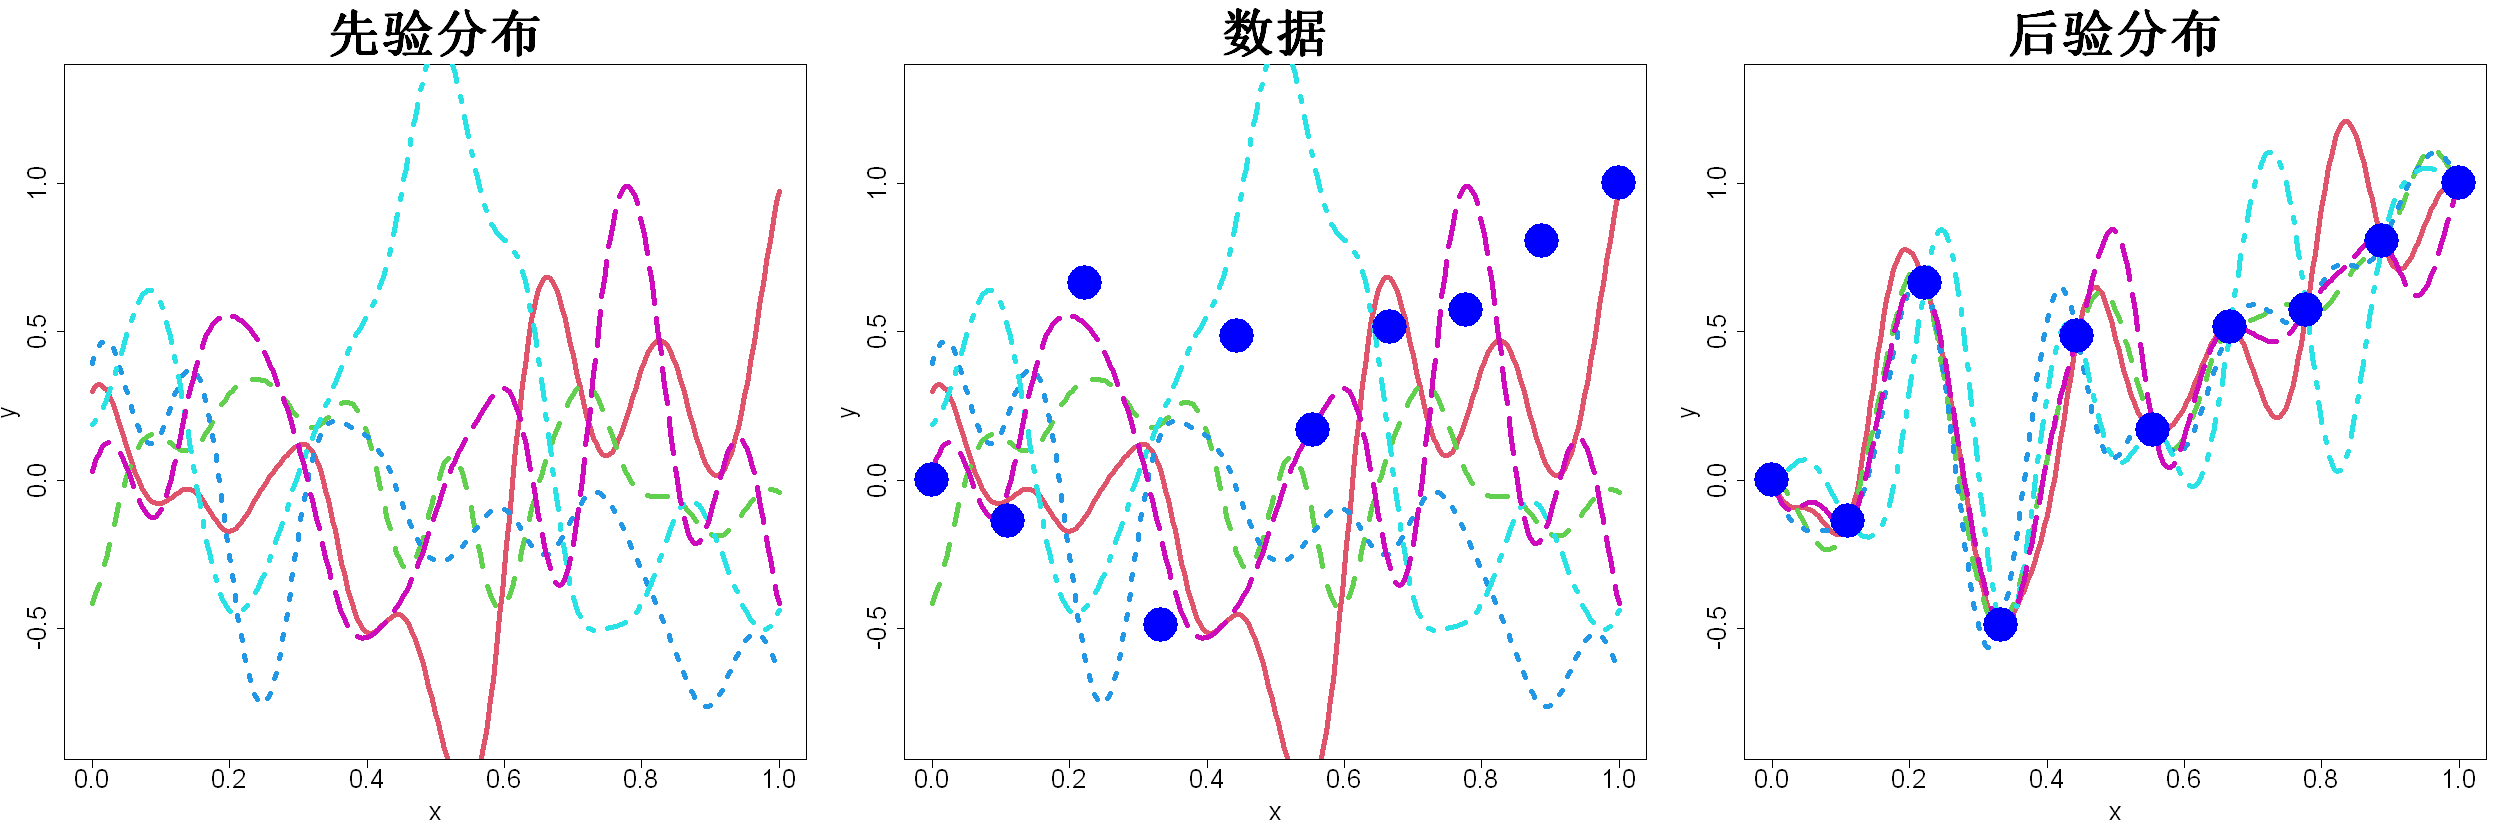

In [15]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/2.5-plot1.RData")){
  f=function(x) sin(10*pi*x)/(1+64*(x-.25)^2)+x^2
  N=301
  test=seq(0,1,length=N) # 301x1
  true=f(test) # 301x1
  n=10
  D=((1:n)-1)/(n-1) # 10x1
  y=f(D) # 10x1
  library(rkriging)
  kernel=Get.Kernel(.08/sqrt(2),type="Gaussian")
  a=Fit.Kriging(D,y,fit=FALSE,kernel=kernel)
  tau2=Get.Kriging.Parameters(a)$nu2
  pred=Predict.Kriging(a,test)
  set.seed(1)
  library(MASS)
  S0=Evaluate.Kernel(kernel,test)
  u1=mvrnorm(n=5,mu=rep(0,N),Sigma=tau2*S0) # 5x301
  R=Evaluate.Kernel(kernel,D)
  L=chol(R+10^(-10)*diag(n))
  library(pdist)
  M=t(as.matrix(pdist(cbind(D),cbind(test))))
  M=exp(-M^2/.08^2)
  b=forwardsolve(t(L),t(M))
  S=tau2*(S0-t(b)%*%b)
  library(Matrix)
  S=nearPD(S)$mat
  me=pred$mean
  set.seed(1)
  u2=mvrnorm(n=5,mu=me,Sigma=S) # 5x301
  u1t=t(u1); u2t=t(u2)
  save(D,y,test,true,u1t,u2t,file="data/2.5-plot1.RData")
}

load("data/2.5-plot1.RData")

options(repr.plot.width=21,repr.plot.height=7)
par(mfrow=c(1,3))
matplot(test,u1t,type="l",xlab="x",ylab="y",cex.lab=2,col=2:6,lwd=4,ylim=c(min(true)-.25,max(true)+.25),cex.axis=2,main="先验分布",cex.main=4)
matplot(test,u1t,type="l",xlab="x",ylab="y",col=2:6,lwd=4,ylim=c(min(true)-.25,max(true)+.25),main="数据",cex.main=4,cex.axis=2,cex.lab=2)
points(D,y,pch=16,cex=6,col="blue")
matplot(test,u2t,type="l",xlab="x",ylab="y",col=2:6,lwd=4,ylim=c(min(true)-.25,max(true)+.25),main="后验分布",cex.main=4,cex.axis=2,cex.lab=2)
points(D,y,pch=16,cex=6,col="blue")

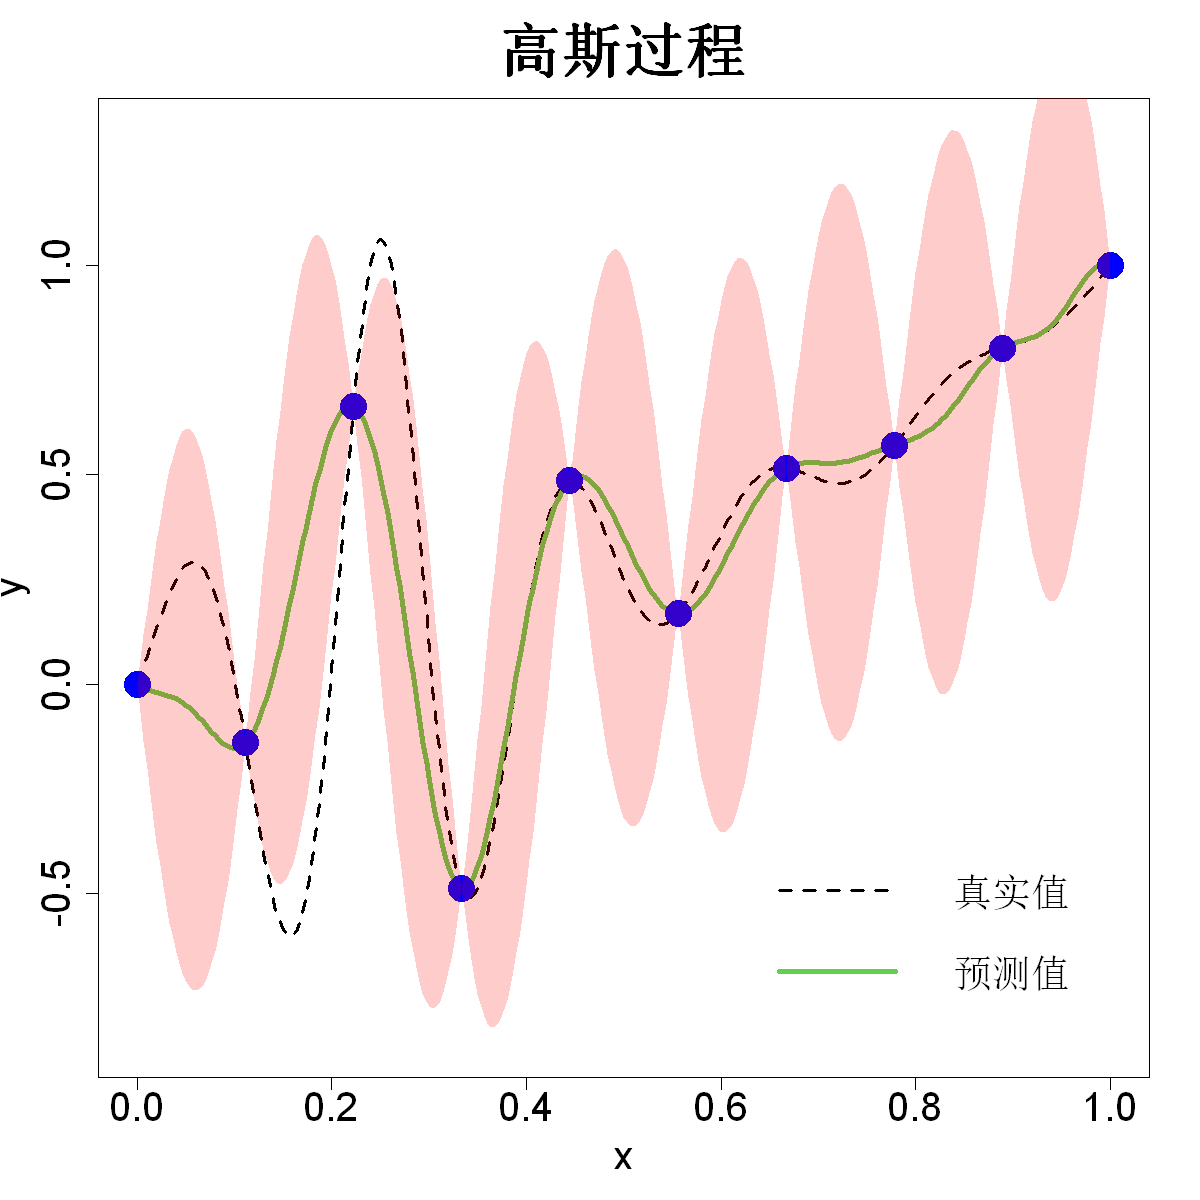

In [16]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/2.5-plot2.RData")){
  f=function(x) sin(10*pi*x)/(1+64*(x-.25)^2)+x^2
  N=301
  test=seq(0,1,length=N) # 301x1
  true=f(test) # 301x1
  n=10
  D=((1:n)-1)/(n-1) # 10x1
  y=f(D) # 10x1
  library(rkriging)
  a=Fit.Kriging(D,y,kernel.parameters=list(type="Gaussian"))
  para=Get.Kriging.Parameters(a)
  pred=Predict.Kriging(a,test)
  low=pred$mean-2*pred$sd
  up=pred$mean+2*pred$sd
  pred=pred$mean
  mu=para$mu; nu2=para$nu2; theta=para$lengthscale
  save(D,y,test,true,pred,low,up,file="data/2.5-plot2.RData")
}

load("data/2.5-plot2.RData")

options(repr.plot.width=10,repr.plot.height=10)
plot(test,true,type="l",xlab="x",ylab="y",cex.lab=2,lwd=3,lty=2,col=1,ylim=c(min(true)-.25,max(true)+.25),cex.axis=2,main="高斯过程",cex.main=3)
lines(test,pred,col=3,lwd=4)
points(cbind(D,y),pch=16,cex=3,col="blue")
polygon(c(test,rev(test)),c(low,rev(up)),col=adjustcolor("red",alpha.f=0.2),border=NA)
legend(.6,-.3,legend=c("真实值","预测值"),lty=c(2,1),col=c(1,3),lwd=c(3,4),bty="n",cex=2)

> **图 2.6** 采用 10 个等间隔设计点、两次重复试验开展多项式回归分析。左侧图像为三次多项式拟合结果，右侧为八次多项式拟合结果，阴影区域代表 95% 预测区间。

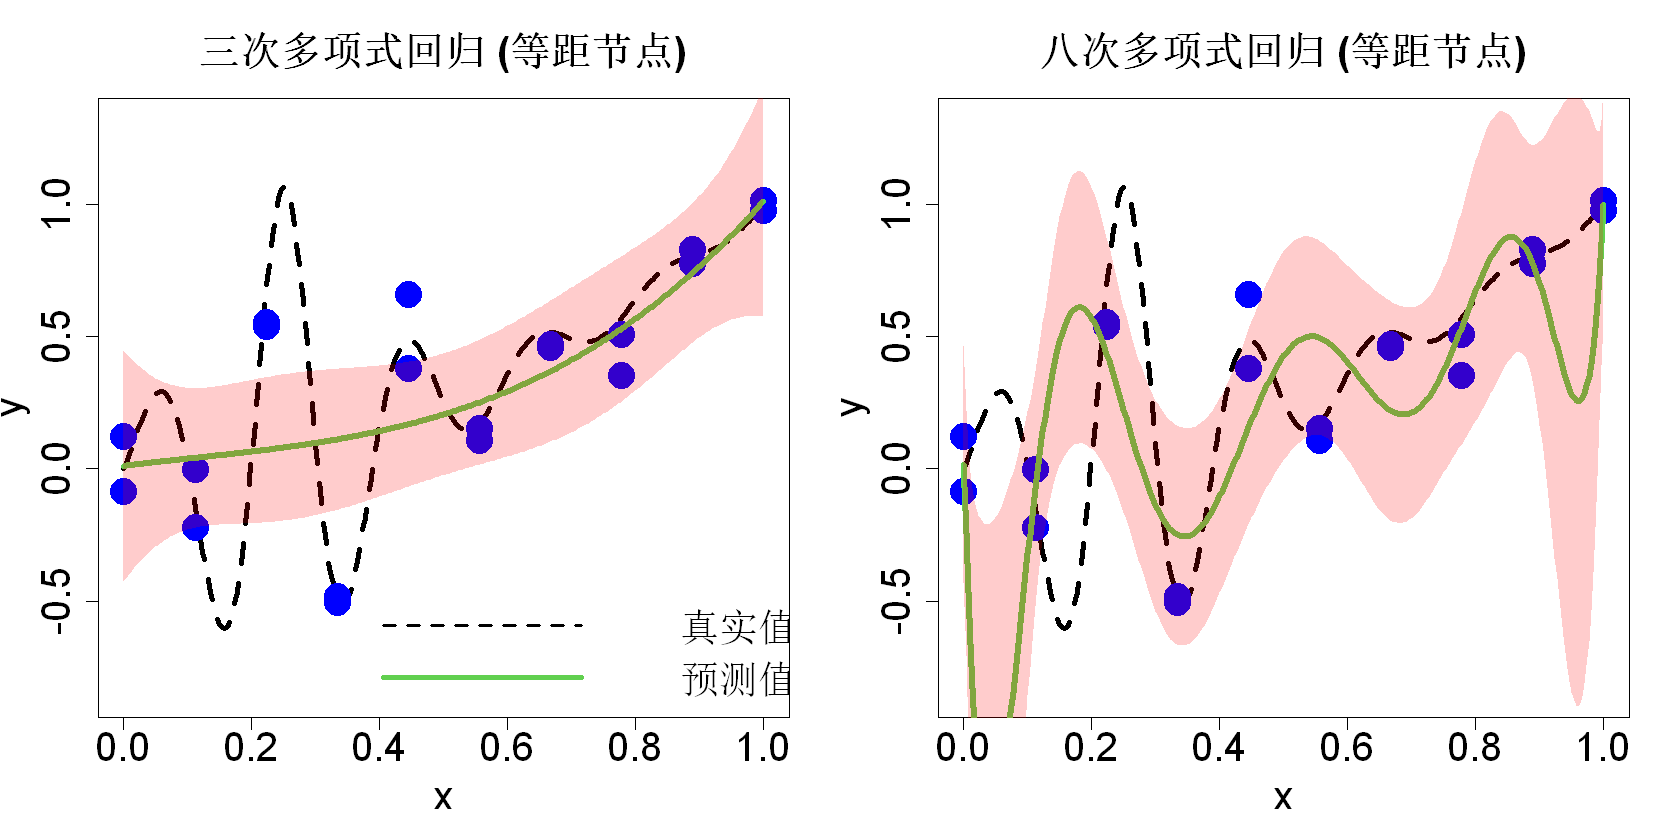

In [17]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/2.6-plot.RData")){
  f=function(x) sin(10*pi*x)/(1+64*(x-.25)^2)+x^2
  test=seq(0,1,length=301) # 301x1
  true=f(test) # 301x1
  set.seed(5)
  n=10; r=2
  D=((1:n)-1)/(n-1)
  D=rep(D,r) # 20x1
  e=rnorm(n*r,sd=.1)
  y=f(D)+e # 20x1
  u=seq(0,1,length=301)
  us=2*u-1
  d=2*D-1
  i=3
  a.lm=lm(y~poly(d,i))
  pred1=predict(a.lm,newdata=data.frame(d=us),interval="confidence")
  mean1=pred1[,1]; low1=pred1[,2]; up1=pred1[,3] # 301x1
  i=8
  a.lm=lm(y~poly(d,i))
  pred2=predict(a.lm,newdata=data.frame(d=us),interval="confidence")
  mean2=pred2[,1]; low2=pred2[,2]; up2=pred2[,3] # 301x1
  save(D,y,test,true,mean1,low1,up1,mean2,low2,up2,file="data/2.6-plot.RData")
}

load("data/2.6-plot.RData")

options(repr.plot.width=14,repr.plot.height=7)
par(mfrow=c(1,2))
plot(test,true,type="l",lty=2,lwd=4,xlab="x",ylab="y",cex.lab=2,ylim=c(min(true)-.25,max(true)+.25),cex.axis=2,main="三次多项式回归 (等距节点)",cex.main=2)
points(D,y,pch=16,cex=3,col="blue")
lines(test,mean1,col=3,lwd=5)
polygon(c(test,rev(test)),c(low1,rev(up1)),col=adjustcolor("red",0.2),border=NA)
legend(.25,-.4,legend=c("真实值","预测值"),lty=c(2,1),col=c(1,3),lwd=c(3,4),bty="n",cex=2)
plot(test,true,type="l",lty=2,lwd=4,xlab="x",ylab="y",cex.lab=2,ylim=c(min(true)-.25,max(true)+.25),cex.axis=2,main="八次多项式回归 (等距节点)",cex.main=2)
points(D,y,pch=16,cex=3,col="blue")
lines(test,mean2,col=3,lwd=5)
polygon(c(test,rev(test)),c(low2,rev(up2)),col=adjustcolor("red",0.2),border=NA)

> **图 2.7** 采用 10 个 D 最优设计点并设置两组重复试验的多项式回归。左侧图表为三次多项式拟合结果，右侧为八次多项式拟合结果，阴影区域代表 95% 预测区间。

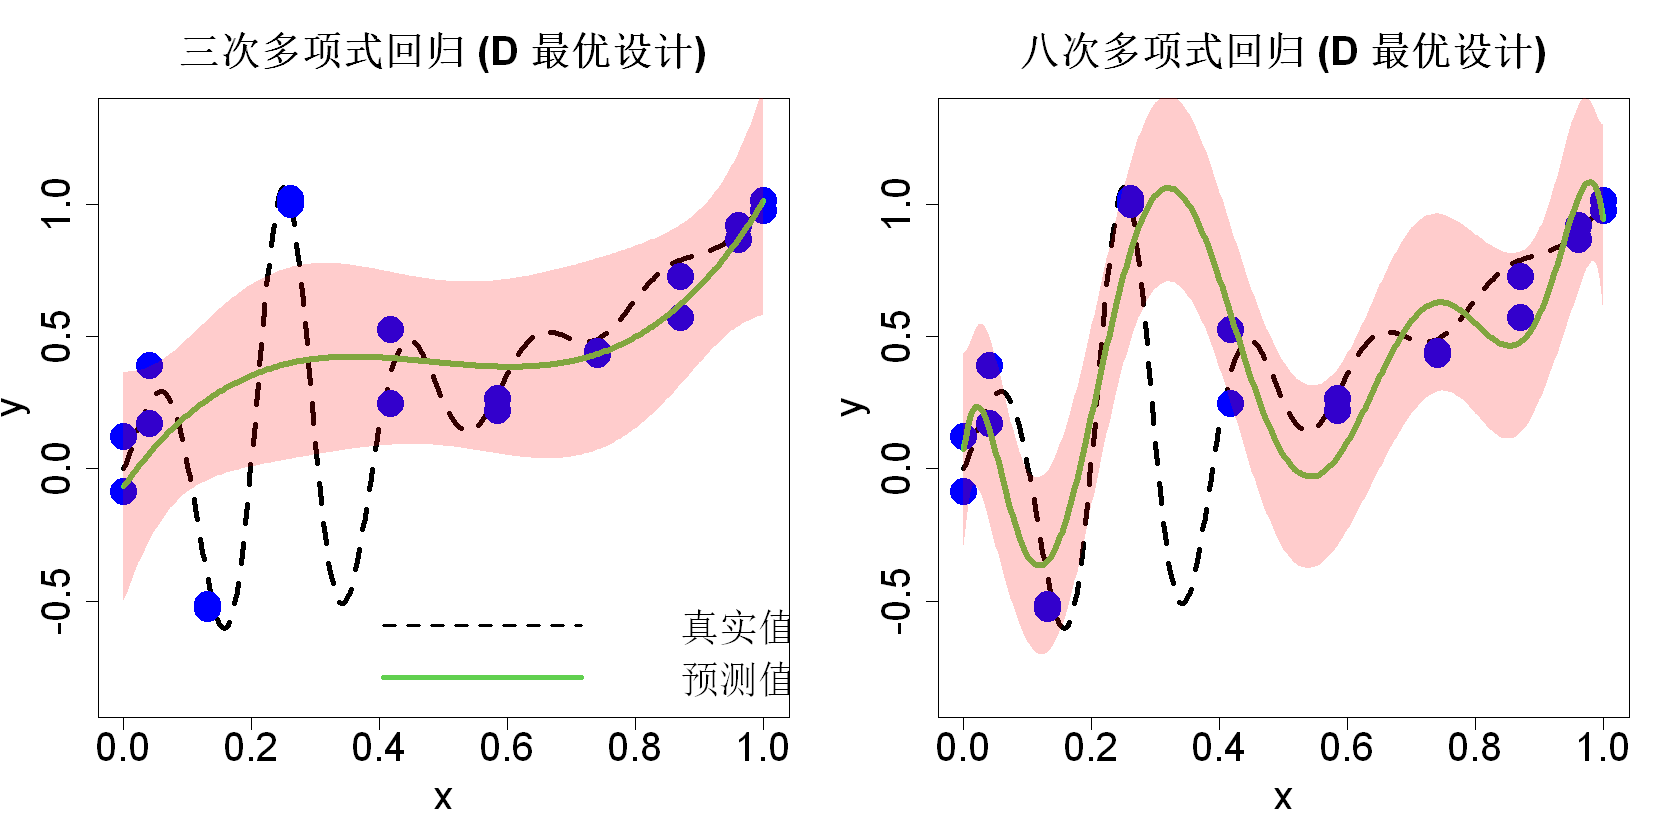

In [18]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/2.7-plot.RData")){
  f=function(x) sin(10*pi*x)/(1+64*(x-.25)^2)+x^2
  test=seq(0,1,length=301) # 301x1
  true=f(test) # 301x1
  n=10; r=2
  set.seed(5)
  e=rnorm(n*r,sd=.1)
  library(AlgDesign)
  cand=data.frame(x=seq(-1,1,length=301))
  a=optFederov(~1+x+I(x^2)+I(x^3)+I(x^4)+I(x^5)+I(x^6)+I(x^7)+I(x^8)+I(x^9),nTrials=n,data=cand,approximate=FALSE)
  D=rep(c(a$design[,1]),r)
  D=(D+1)/2 # 20x1
  y=f(D)+e # 20x1
  u=seq(0,1,length=301)
  us=2*u-1
  d=2*D-1
  i=3
  a.lm=lm(y~poly(d,i))
  pred1=predict(a.lm,newdata=data.frame(d=us),interval="confidence")
  mean1=pred1[,1]; low1=pred1[,2]; up1=pred1[,3] # 301x1
  i=8
  a.lm=lm(y~poly(d,i))
  pred2=predict(a.lm,newdata=data.frame(d=us),interval="confidence")
  mean2=pred2[,1]; low2=pred2[,2]; up2=pred2[,3] # 301x1
  save(D,y,test,true,mean1,low1,up1,mean2,low2,up2,file="data/2.7-plot.RData")
}

load("data/2.7-plot.RData")

options(repr.plot.width=14,repr.plot.height=7)
par(mfrow=c(1,2))
plot(test,true,type="l",lty=2,lwd=4,xlab="x",ylab="y",cex.lab=2,ylim=c(min(true)-.25,max(true)+.25),cex.axis=2,main="三次多项式回归 (D 最优设计)",cex.main=2)
points(D,y,pch=16,cex=3,col="blue")
lines(test,mean1,col=3,lwd=5)
polygon(c(test,rev(test)),c(low1,rev(up1)),col=adjustcolor("red",0.2),border=NA)
legend(.25,-.4,legend=c("真实值","预测值"),lty=c(2,1),col=c(1,3),lwd=c(3,4),bty="n",cex=2)
plot(test,true,type="l",lty=2,lwd=4,xlab="x",ylab="y",cex.lab=2,ylim=c(min(true)-.25,max(true)+.25),cex.axis=2,main="八次多项式回归 (D 最优设计)",cex.main=2)
points(D,y,pch=16,cex=3,col="blue")
lines(test,mean2,col=3,lwd=5)
polygon(c(test,rev(test)),c(low2,rev(up2)),col=adjustcolor("red",0.2),border=NA)

> **图 2.8** 采用 10 个等间隔设计点（左侧）与 D 最优设计点（右侧）、各设置两组重复试验的核岭回归。

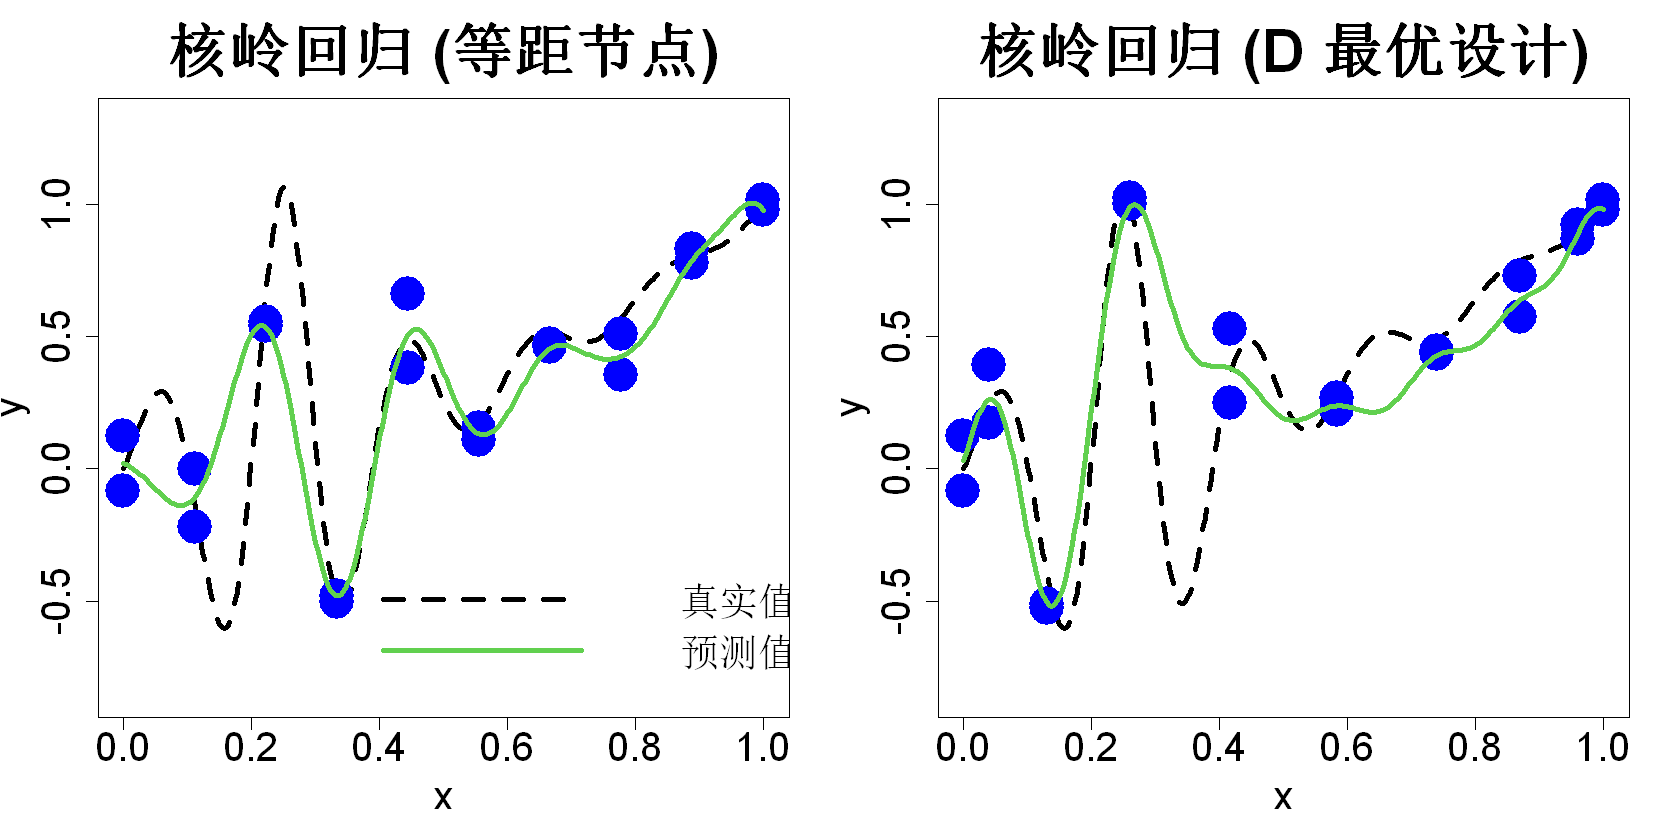

In [19]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/2.8-plot.RData")){
  f=function(x) sin(10*pi*x)/(1+64*(x-.25)^2)+x^2
  test=seq(0,1,length=301) # 301x1
  true=f(test) # 301x1
  set.seed(5)
  n=10; re=2
  D1=((1:n)-1)/(n-1)
  D1=rep(D1,re) # 20x1
  e=rnorm(n*re,sd=.1)
  y1=f(D1)+e # 20x1
  E1=as.matrix(dist(D1)) # 20x20
  MSCV=function(para,E,y){
    theta=para[1]; lam=para[2]
    R=exp(-(E/theta)^2)
    Rinv=solve(R+lam*diag(n*re))
    cv=c(Rinv%*%y)/diag(Rinv)
    log(mean(cv^2))
  }
  GCV=function(para,E,y){
    theta=para[1]; lam=para[2]
    R=exp(-(E/theta)^2)
    Rinv=solve(R+lam*diag(n*re))
    cv=c(Rinv%*%y)/mean(diag(Rinv))
    log(mean(cv^2))
  }
  #等距设计：MSCV
  a=optim(c(.1,.1),function(pa) MSCV(pa,E1,y1),lower=c(.05,.001),upper=c(1,1),method="L-BFGS-B")
  theta1=a$par[1]; lam1=a$par[2]
  R=exp(-(E1/theta1)^2)
  coef=solve(R+lam1*diag(n*re),y1)
  basis=function(h) exp(-(h/theta1)^2)
  r=function(x) basis(x-D1)
  fhat=function(x) sum(r(x)*coef)
  pred1=test
  for(i in 1:301) pred1[i]=fhat(test[i]) # 301x1
  #等距设计：GCV
  a=optim(c(.1,.1),function(pa) GCV(pa,E1,y1),lower=c(.05,.001),upper=c(1,1),method="L-BFGS-B")
  theta2=a$par[1]; lam2=a$par[2]
  #D 最优设计
  library(AlgDesign)
  cand=data.frame(x=seq(-1,1,length=301))
  a=optFederov(~1+x+I(x^2)+I(x^3)+I(x^4)+I(x^5)+I(x^6)+I(x^7)+I(x^8)+I(x^9),nTrials=n,data=cand,approximate=FALSE)
  D2=rep(c(a$design[,1]),re)
  D2=(D2+1)/2 # 20x1
  y2=f(D2)+e # 20x1
  E2=as.matrix(dist(D2)) # 20x20
  a=optim(c(.1,.1),function(pa) MSCV(pa,E2,y2),lower=c(.05,.001),upper=c(1,1),method="L-BFGS-B")
  theta3=a$par[1]; lam3=a$par[2]
  R=exp(-(E2/theta3)^2)
  coef=solve(R+lam3*diag(n*re),y2)
  basis=function(h) exp(-(h/theta3)^2)
  r=function(x) basis(x-D2)
  fhat=function(x) sum(r(x)*coef)
  pred2=test
  for(i in 1:301) pred2[i]=fhat(test[i]) # 301x1
  save(D1,y1,D2,y2,test,true,pred1,pred2,file="data/2.8-plot.RData")
}

load("data/2.8-plot.RData")

options(repr.plot.width=14,repr.plot.height=7)
par(mfrow=c(1,2))
plot(test,true,type="l",lwd=4,lty=2,xlab="x",ylab="y",cex.lab=2,ylim=c(min(true)-.25,max(true)+.25),cex.axis=2,main="核岭回归 (等距节点)",cex.main=3)
points(D1,y1,pch=16,cex=4,col="blue")
lines(test,pred1,col=3,lwd=4)
legend(.25,-.3,legend=c("真实值","预测值"),lty=c(2,1),col=c(1,3),lwd=c(4,4),bty="n",cex=2)
plot(test,true,type="l",lwd=4,lty=2,xlab="x",ylab="y",cex.lab=2,ylim=c(min(true)-.25,max(true)+.25),cex.axis=2,main="核岭回归 (D 最优设计)",cex.main=3)
points(D2,y2,pch=16,cex=4,col="blue")
lines(test,pred2,col=3,lwd=4)

> **图 2.9** 采用 10 点等间隔设计点（左侧）与 10 点 D 最优设计点（右侧）并设置两组重复试验的高斯过程回归。

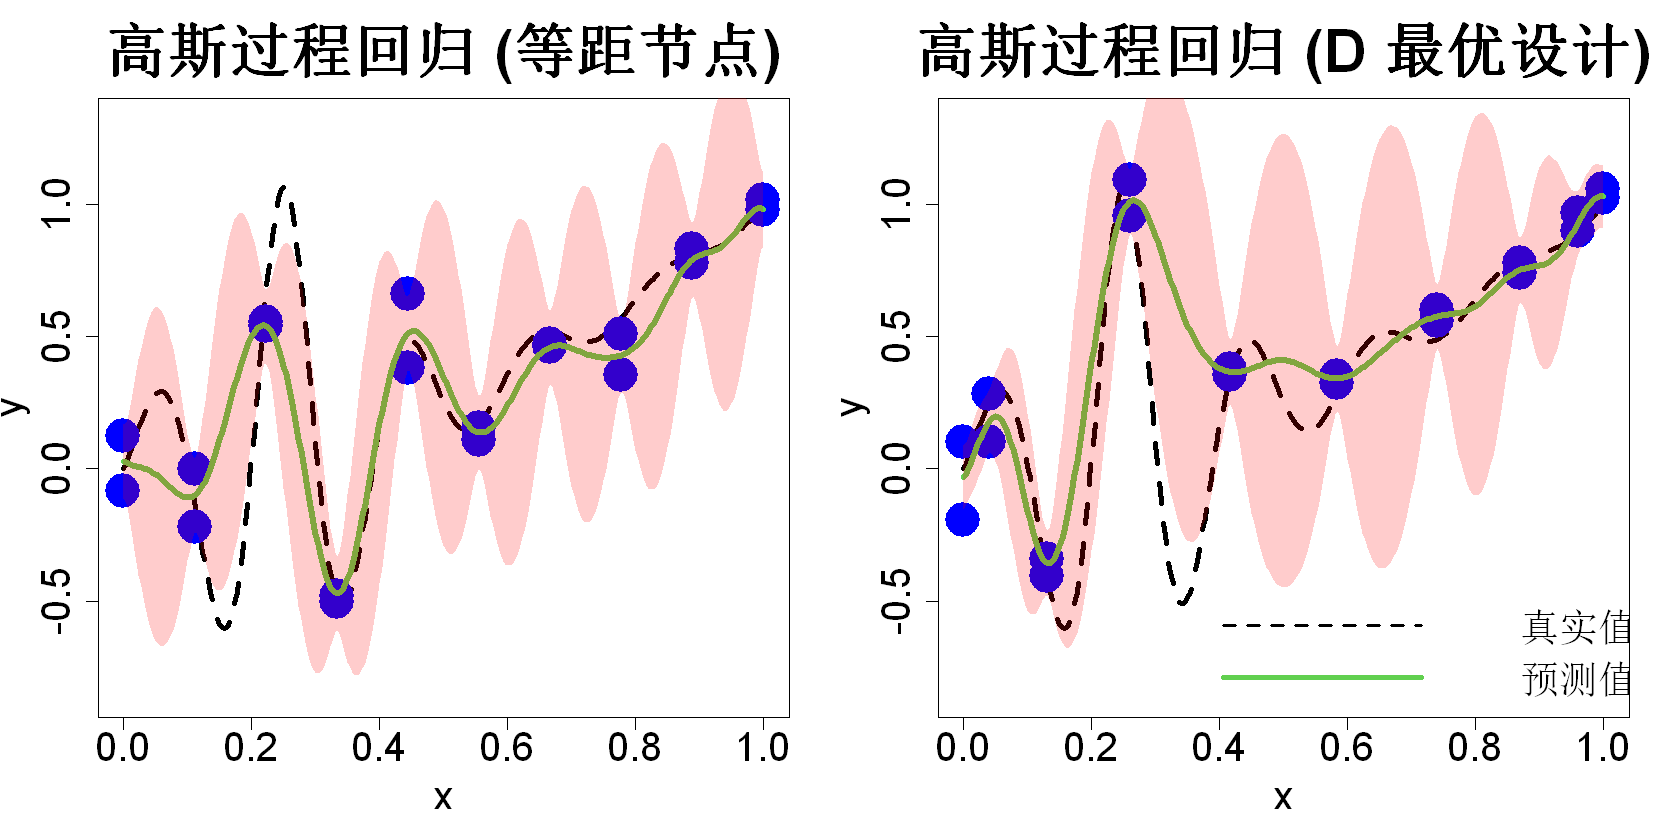

In [20]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/2.9-plot.RData")){
  library(rkriging)
  f=function(x) sin(10*pi*x)/(1+64*(x-.25)^2)+x^2
  test=seq(0,1,length=301) # 301x1
  true=f(test) # 301x1
  set.seed(5)
  n=10; re=2
  #等距设计
  D1=((1:n)-1)/(n-1)
  D1=rep(D1,re) # 20x1
  e=rnorm(n*re,sd=.1)
  y1=f(D1)+e # 20x1
  a=Fit.Kriging(D1,y1,interpolation=FALSE,kernel.parameters=list(type="Gaussian"))
  pred1=Predict.Kriging(a,test)
  mean1=pred1$mean; low1=mean1-2*pred1$sd; up1=mean1+2*pred1$sd # 301x1
  #D 最优设计
  library(AlgDesign)
  cand=data.frame(x=seq(-1,1,length=301))
  a=optFederov(~1+x+I(x^2)+I(x^3)+I(x^4)+I(x^5)+I(x^6)+I(x^7)+I(x^8)+I(x^9),nTrials=n,data=cand,approximate=FALSE)
  D2=rep(c(a$design[,1]),re)
  D2=(D2+1)/2 # 20x1
  e=rnorm(n*re,sd=.1)
  y2=f(D2)+e # 20x1
  a=Fit.Kriging(D2,y2,interpolation=FALSE,kernel.parameters=list(type="Gaussian"))
  pred2=Predict.Kriging(a,test)
  mean2=pred2$mean; low2=mean2-2*pred2$sd; up2=mean2+2*pred2$sd # 301x1
  save(D1,y1,D2,y2,test,true,mean1,low1,up1,mean2,low2,up2,file="data/2.9-plot.RData")
}

load("data/2.9-plot.RData")

options(repr.plot.width=14,repr.plot.height=7)
par(mfrow=c(1,2))
plot(test,true,type="l",lty=2,lwd=4,xlab="x",ylab="y",ylim=c(min(true)-.25,max(true)+.25),main="高斯过程回归 (等距节点)",cex.main=3,cex.lab=2,cex.axis=2)
points(D1,y1,pch=16,cex=4,col="blue")
lines(test,mean1,col=3,lwd=5)
polygon(c(test,rev(test)),c(low1,rev(up1)),col=adjustcolor("red",0.2),border=NA)
plot(test,true,type="l",lty=2,lwd=4,xlab="x",ylab="y",ylim=c(min(true)-.25,max(true)+.25),main="高斯过程回归 (D 最优设计)",cex.main=3,cex.lab=2,cex.axis=2)
points(D2,y2,pch=16,cex=4,col="blue")
lines(test,mean2,col=3,lwd=5)
polygon(c(test,rev(test)),c(low2,rev(up2)),col=adjustcolor("red",0.2),border=NA)
legend(.25,-.4,legend=c("真实值","预测值"),lty=c(2,1),col=c(1,3),lwd=c(3,4),bty="n",cex=2)